# Oscillator Behaviour Analysis
## Rectifier + Comparator for 12 Waveform Parameter Positions

Python implementation of the `rectifier`, `comparator`, `setWaveformParameters` and `nextSample` functions from `Oscillator.cpp`.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.io.wavfile import write

## 1. Function implementations

In [39]:
# -----------------------------------------------------------------------
# Constants (from Oscillator.h)
# -----------------------------------------------------------------------
SPLIT_POINT_A = 0.4
SPLIT_POINT_B = 0.8


# -----------------------------------------------------------------------
# setWaveformParameters  (Oscillator.cpp)
# -----------------------------------------------------------------------
def set_waveform_parameters(value):
    """Returns (rectThreshold, rectGain, compThreshold, compGain) for
    a potentiometer position `value` in [0.0, 1.1]."""

    if value < SPLIT_POINT_A: # 0-0.4: rectifier
        pos = value / SPLIT_POINT_A
        return pos, 1.0, 0.0, 0.0

    elif value <= SPLIT_POINT_B: # 0.4-0.8: rectifier+comparator
        pos = (value - SPLIT_POINT_A) / (SPLIT_POINT_B - SPLIT_POINT_A)
        return 1.0, 1.0 - pos, 0.0, pos

    else: # 0.8-1.1: comparator
        pos = (SPLIT_POINT_B - value - 0.5 - 0.6 * (value - SPLIT_POINT_B)) / (1.2 - SPLIT_POINT_B)
        return 1.0, 0.0, pos, 1.0


# -----------------------------------------------------------------------
# rectifier  (Oscillator.cpp)
# -----------------------------------------------------------------------
def rectifier(input_sample, threshold):
    """Rectifier with reflection and DC offset compensation."""
    if input_sample <= threshold:
        output = input_sample
    else:
        output = threshold - (threshold + 1.0) * input_sample
    return output + (1.0 - threshold) / 2.0


# Vectorised version for numpy arrays
rectifier_vec = np.vectorize(rectifier)

# ORIGINAL
# -----------------------------------------------------------------------
# comparator  (Oscillator.cpp)
# -----------------------------------------------------------------------
#def comparator(input_sample, threshold, position):
#    """Comparator with dual mode (bipolar / unipolar) and threshold rescaling."""
#    threshold = (threshold + 0.2) * 0.4

#    if position < SPLIT_POINT_B:       # Bipolar mode: -1 / +1
#        return -1.0 if input_sample > threshold else 1.0
#    else:                              # Unipolar mode: 0 / 1
#        return 0.0 if input_sample > threshold else 1.0

#comparator_vec = np.vectorize(comparator)

TRANSITION_WIDTH = 0.0

def comparator(input_sample, threshold, position):
    """
    Comparator with smooth transition around SPLIT_POINT_B.

    Before the transition zone:
        bipolar (-1 / +1)

    After the transition zone:
        unipolar (0 / +1)

    Inside the transition zone:
        linear crossfade between both modes.
    """
    threshold = (threshold + 0.2) * 0.4

    bipolar = -1.0 if input_sample > threshold else 1.0
    unipolar = 0.0 if input_sample > threshold else 1.0

    # Original behaviour
    if TRANSITION_WIDTH <= 0:
        return bipolar if position < SPLIT_POINT_B else unipolar

    start = SPLIT_POINT_B - TRANSITION_WIDTH
    end   = SPLIT_POINT_B + TRANSITION_WIDTH

    if position <= start:
        return bipolar
    if position >= end:
        return unipolar
    
    # Crossfade
    t = (position - start) / (end - start)

    return (1.0 - t) * bipolar + t * unipolar

comparator_vec = np.vectorize(comparator)


# -----------------------------------------------------------------------
# next_sample  (Oscillator.cpp) -- stateless version applied to a phase array
# -----------------------------------------------------------------------
def compute_samples(phase_array, position, amplitude=1.0):
    """Generates a sample array for a given waveform position.

    phase_array: phase values in [0, 1)
    position:    potentiometer value [0.0, 1.1]
    """
    rect_thr, rect_gain, comp_thr, comp_gain = set_waveform_parameters(position)

    sawtooth = 2.0 * phase_array - 1.0 # Sawtooth wave in [-1, +1]

    rect_sig = rectifier_vec(sawtooth, rect_thr)  * rect_gain
    comp_sig = comparator_vec(sawtooth, comp_thr, position) * comp_gain

    return amplitude * (rect_sig + comp_sig) / 2.0


print("Functions defined successfully.")

Functions defined successfully.


## 2. Direct Comparison: JS vs C++ Rectifier

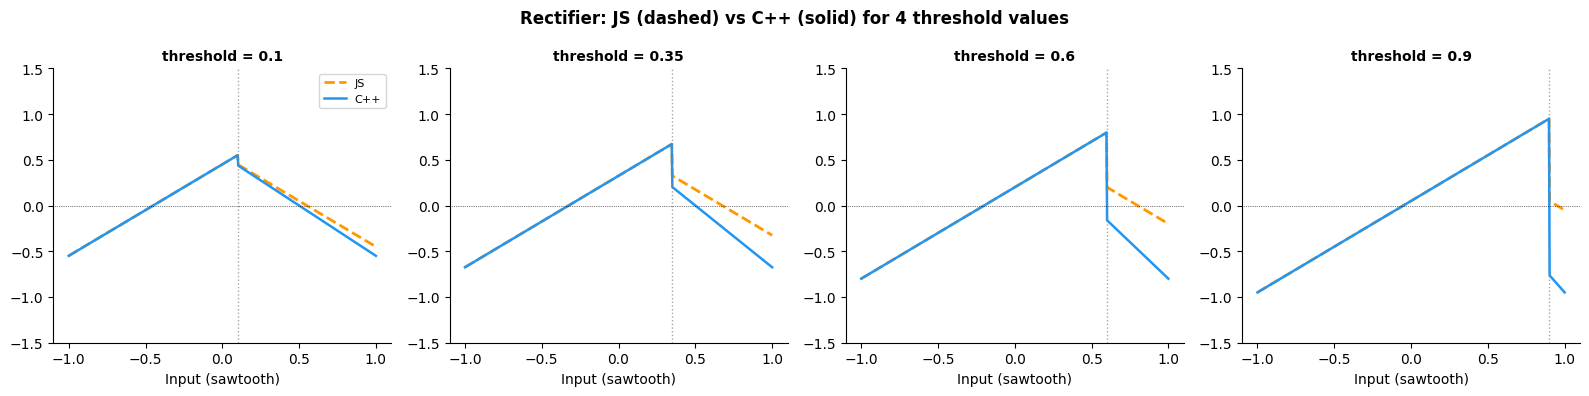

Figure saved as rectifier_js_vs_cpp.png


In [42]:
def rectifier_js(input_sample, threshold):
    """Original JavaScript version (unit slope)."""
    if input_sample <= threshold:
        output = input_sample
    else:
        output = threshold - input_sample     # slope -1
    return output + (1.0 - threshold) / 2.0

rectifier_js_vec = np.vectorize(rectifier_js)

# Show the difference for 4 representative threshold values
thresholds_test = [0.1, 0.35, 0.6, 0.9]
x = np.linspace(-1.0, 1.0, 512)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Rectifier: JS (dashed) vs C++ (solid) for 4 threshold values",
             fontsize=12, fontweight='bold')

for ax, thr in zip(axes, thresholds_test):
    y_js  = rectifier_js_vec(x, thr)
    y_cpp = rectifier_vec(x, thr)

    ax.plot(x, y_js,  lw=2,   ls='--', color='#FF9800', label='JS')
    ax.plot(x, y_cpp, lw=1.8, color='#2196F3', label='C++')
    ax.axvline(thr, color='gray', lw=1, ls=':', alpha=0.7)
    ax.axhline(0,   color='black', lw=0.5, ls=':')
    ax.set_title(f"threshold = {thr}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Input (sawtooth)")
    ax.set_ylim(-1.5, 1.5)
    ax.spines[['top','right']].set_visible(False)
    if thr == thresholds_test[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('rectifier_js_vs_cpp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as rectifier_js_vs_cpp.png")

## 3. Generation of the 12 Waveform Positions

In [40]:
# 12 uniformly distributed positions between 0.0 and 1.1
N_POSITIONS = 12
N_SAMPLES   = 512        # samples per cycle

positions = np.linspace(0.0, 1.1, N_POSITIONS)
phase     = np.linspace(0.0, 1.0, N_SAMPLES, endpoint=False)


# Zone label for each position
def zone_label(v):
    if v < SPLIT_POINT_A:
        return "Rectifier"
    elif v <= SPLIT_POINT_B:
        return "Transition"
    else:
        return "Comparator"


for i, p in enumerate(positions):
    rt, rg, ct, cg = set_waveform_parameters(p)
    print(f"pos {i+1:2d} | value={p:.3f} | zone={zone_label(p):10s} | "
          f"rectThr={rt:.3f} rectGain={rg:.3f} | compThr={ct:.3f} compGain={cg:.3f}")

pos  1 | value=0.000 | zone=Rectifier  | rectThr=0.000 rectGain=1.000 | compThr=0.000 compGain=0.000
pos  2 | value=0.100 | zone=Rectifier  | rectThr=0.250 rectGain=1.000 | compThr=0.000 compGain=0.000
pos  3 | value=0.200 | zone=Rectifier  | rectThr=0.500 rectGain=1.000 | compThr=0.000 compGain=0.000
pos  4 | value=0.300 | zone=Rectifier  | rectThr=0.750 rectGain=1.000 | compThr=0.000 compGain=0.000
pos  5 | value=0.400 | zone=Transition | rectThr=1.000 rectGain=1.000 | compThr=0.000 compGain=0.000
pos  6 | value=0.500 | zone=Transition | rectThr=1.000 rectGain=0.750 | compThr=0.000 compGain=0.250
pos  7 | value=0.600 | zone=Transition | rectThr=1.000 rectGain=0.500 | compThr=0.000 compGain=0.500
pos  8 | value=0.700 | zone=Transition | rectThr=1.000 rectGain=0.250 | compThr=0.000 compGain=0.750
pos  9 | value=0.800 | zone=Transition | rectThr=1.000 rectGain=0.000 | compThr=0.000 compGain=1.000
pos 10 | value=0.900 | zone=Comparator | rectThr=1.000 rectGain=0.000 | compThr=-1.650 comp

## 4. Save sweep audio

In [ ]:
# --------------------------------------------------
# Audio settings
# --------------------------------------------------

SR = 44100
DURATION = 12.0 # seconds
FREQ = 110.0 # Hz

# --------------------------------------------------
# Time axis
# --------------------------------------------------

n_samples = int(SR * DURATION)

t = np.arange(n_samples) / SR

# Sweep 0.0 -> 1.1
positions = np.linspace(0.0, 1.1, n_samples)

# Oscillator phase
phase = (t * FREQ) % 1.0

# --------------------------------------------------
# Generate waveform
# --------------------------------------------------

audio = np.empty(n_samples)

for i in range(n_samples):
    audio[i] = compute_samples(
        np.array([phase[i]]),
        positions[i]
    )[0]

# --------------------------------------------------
# Normalization
# --------------------------------------------------

audio /= np.max(np.abs(audio))
audio *= 0.95

# --------------------------------------------------
# Save
# --------------------------------------------------

audio_int16 = (audio * 32767).astype(np.int16)

write(
    "waveform_sweep.wav",
    SR,
    audio_int16
)

print("Saved waveform_sweep.wav")

Saved waveform_sweep.wav


## 5. Plot the 12 waveforms

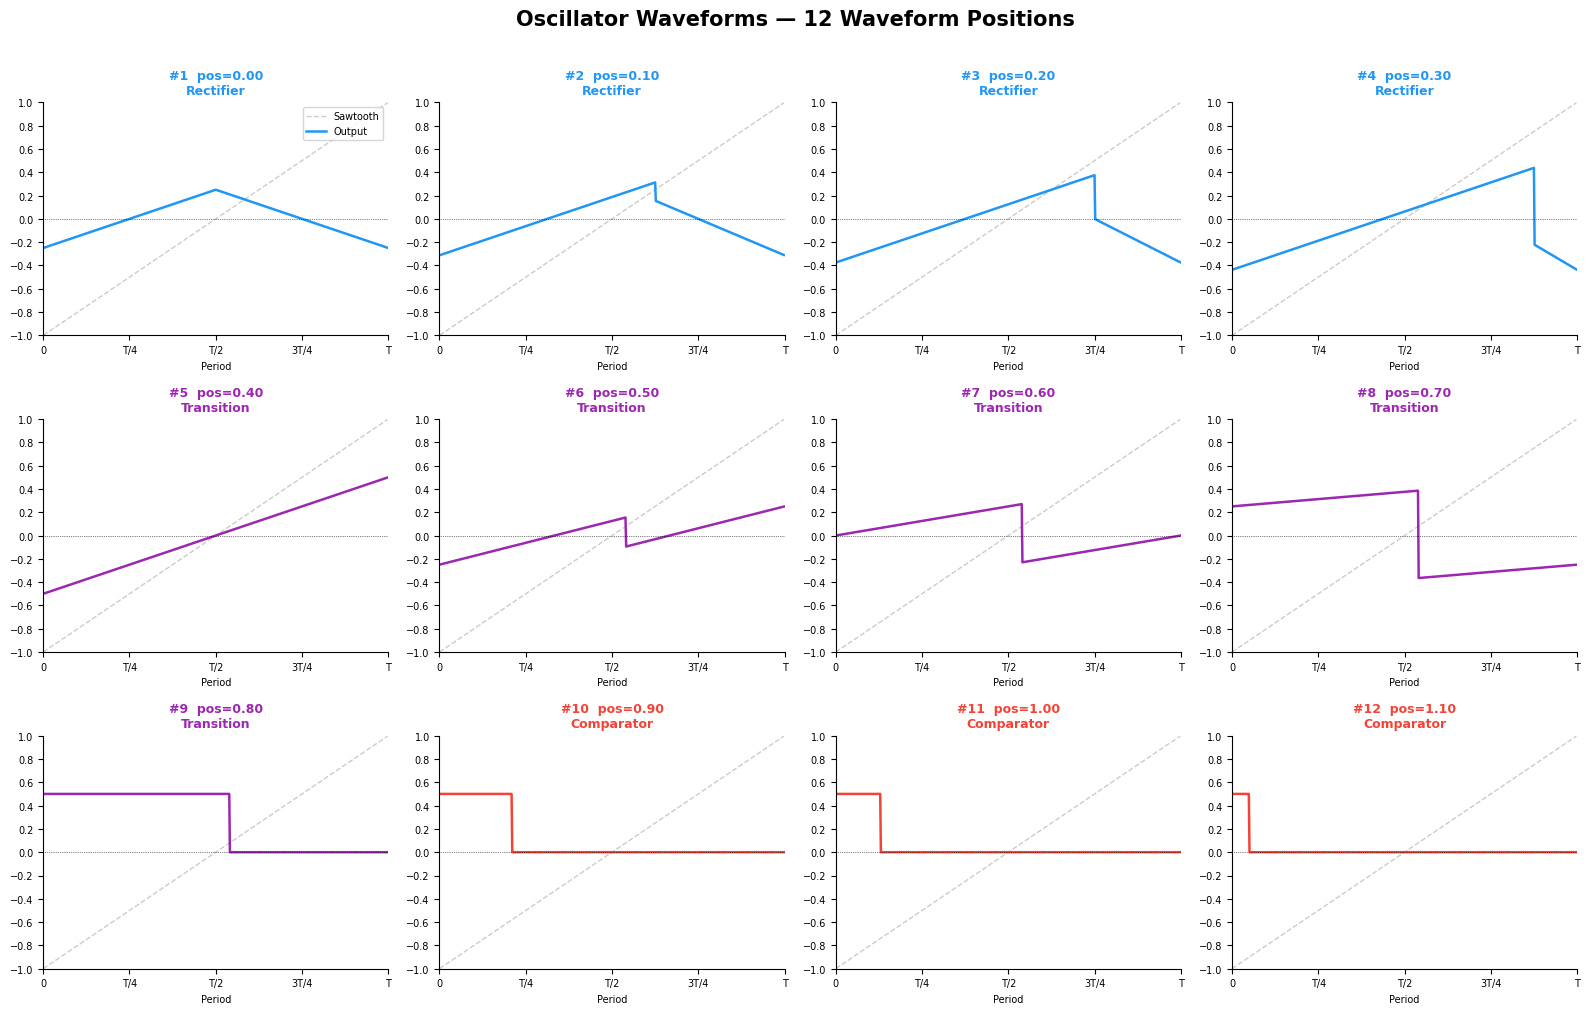

Figure saved as waveforms_12pos.png


In [41]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Oscillator Waveforms — 12 Waveform Positions",
             fontsize=15, fontweight='bold', y=1.01)

# Colors per zone
zone_colors = {
    "Rectifier":  "#2196F3",
    "Transition": "#9C27B0",
    "Comparator": "#F44336",
}

# Reference sawtooth (grey)
sawtooth_ref = 2.0 * phase - 1.0

for idx, (ax, pos) in enumerate(zip(axes.flat, positions)):
    samples = compute_samples(phase, pos)
    zone    = zone_label(pos)
    color   = zone_colors[zone]

    ax.plot(phase, sawtooth_ref, color='#CCCCCC', lw=1, ls='--', label='Sawtooth')
    ax.plot(phase, samples, color=color, lw=1.8, label='Output')

    ax.axhline(0, color='black', lw=0.5, ls=':')
    ax.set_ylim(-1.0, 1.0)
    ax.set_yticks(np.arange(-1.0, 1.1, 0.2))
    ax.set_xlim(0.0, 1.0)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0', 'T/4', 'T/2', '3T/4', 'T'], fontsize=7)
    ax.set_xlabel("Period", fontsize=7)
    ax.set_title(f"#{idx+1}  pos={pos:.2f}\n{zone}", fontsize=9, color=color, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.spines[['top','right']].set_visible(False)

    if idx == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.savefig('waveforms_12pos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as waveforms_12pos.png")

## 6. Plot: Internal Parameter Behaviour vs. Position

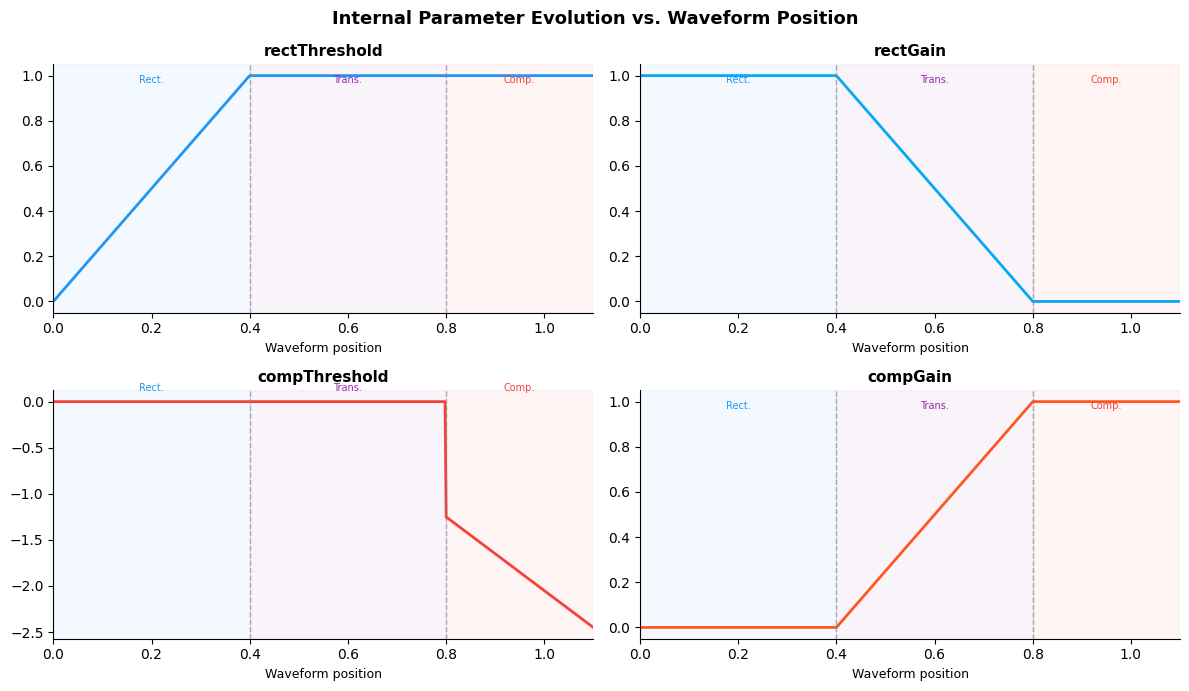

Figure saved as params_evolution.png


In [15]:
pos_range = np.linspace(0.0, 1.1, 500)
params = np.array([set_waveform_parameters(v) for v in pos_range])
rect_thr_arr, rect_gain_arr, comp_thr_arr, comp_gain_arr = params.T

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Internal Parameter Evolution vs. Waveform Position",
             fontsize=13, fontweight='bold')

plot_data = [
    (axes[0,0], rect_thr_arr,  "rectThreshold", "#2196F3"),
    (axes[0,1], rect_gain_arr, "rectGain",      "#03A9F4"),
    (axes[1,0], comp_thr_arr,  "compThreshold", "#F44336"),
    (axes[1,1], comp_gain_arr, "compGain",      "#FF5722"),
]

for ax, data, label, color in plot_data:
    ax.plot(pos_range, data, color=color, lw=2)
    ax.axvline(SPLIT_POINT_A, color='gray', lw=1, ls='--', alpha=0.6)
    ax.axvline(SPLIT_POINT_B, color='gray', lw=1, ls='--', alpha=0.6)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel("Waveform position", fontsize=9)
    ax.set_xlim(0, 1.1)
    ax.spines[['top','right']].set_visible(False)
    # Zone backgrounds
    ax.axvspan(0,             SPLIT_POINT_A, alpha=0.05, color='#2196F3')
    ax.axvspan(SPLIT_POINT_A, SPLIT_POINT_B, alpha=0.05, color='#9C27B0')
    ax.axvspan(SPLIT_POINT_B, 1.1,           alpha=0.05, color='#F44336')
    # Zone labels
    ylim = ax.get_ylim()
    mid_y = ylim[1] * 0.92
    ax.text(SPLIT_POINT_A/2,                 mid_y, 'Rect.',  ha='center', fontsize=7, color='#2196F3')
    ax.text((SPLIT_POINT_A+SPLIT_POINT_B)/2, mid_y, 'Trans.', ha='center', fontsize=7, color='#9C27B0')
    ax.text((SPLIT_POINT_B+1.1)/2,           mid_y, 'Comp.',  ha='center', fontsize=7, color='#F44336')

plt.tight_layout()
plt.savefig('params_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as params_evolution.png")